In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import seaborn as sns

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving churn.csv to churn.csv


In [ ]:
file_name = list(uploaded.keys())[0]
churn = pd.read_csv(file_name)
churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
churn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
churn['SeniorCitizen'] = churn['SeniorCitizen'].astype('object')

In [ ]:
churn.describe()

,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7032.000000
mean,32.371149,64.761692,2283.300441
std,24.559481,30.090047,2266.771362
min,0.000000,18.250000,18.800000
25%,9.000000,35.500000,401.450000
50%,29.000000,70.350000,1397.475000
75%,55.000000,89.850000,3794.737500
max,72.000000,118.750000,8684.800000


In [ ]:
dup= churn.duplicated().sum()
print("duplicated values :" , dup)

duplicated values : 0


In [ ]:
null_values = churn.isna()
print("null values are : " , null_values)

null values are :        customerID  gender  SeniorCitizen  Partner  Dependents  tenure  \
0          False   False          False    False       False   False   
1          False   False          False    False       False   False   
2          False   False          False    False       False   False   
3          False   False          False    False       False   False   
4          False   False          False    False       False   False   
...          ...     ...            ...      ...         ...     ...   
7038       False   False          False    False       False   False   
7039       False   False          False    False       False   False   
7040       False   False          False    False       False   False   
7041       False   False          False    False       False   False   
7042       False   False          False    False       False   False   

      PhoneService  MultipleLines  InternetService  OnlineSecurity  ...  \
0            False          False        

In [ ]:
null_values = churn.isna().sum()
print("null values are : " , null_values)

null values are :  customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
df_copy = churn.copy()

if "TotalCharges" in df_copy.columns:
    df_copy["TotalCharges"] = churn['MonthlyCharges'] * churn['tenure']

null_values = df_copy.isna().sum()
print("null values are : " , null_values)

null values are :  customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [ ]:
num_cols = df_copy.select_dtypes(include=[np.number]).columns.tolist()
num_cols

['tenure', 'MonthlyCharges', 'TotalCharges']

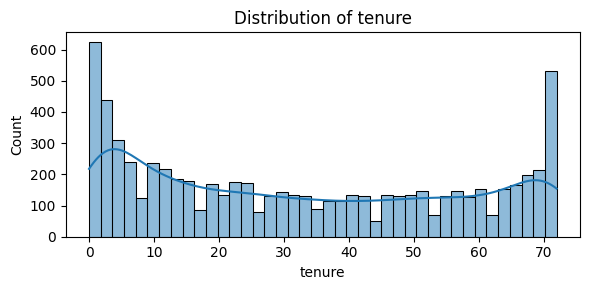

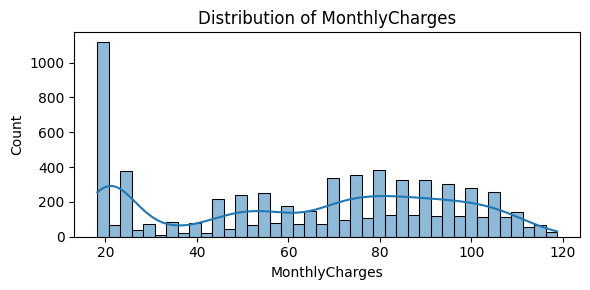

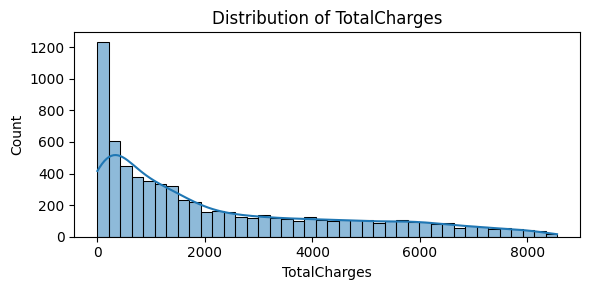

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(df_copy[col], kde=True, bins=40)
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()

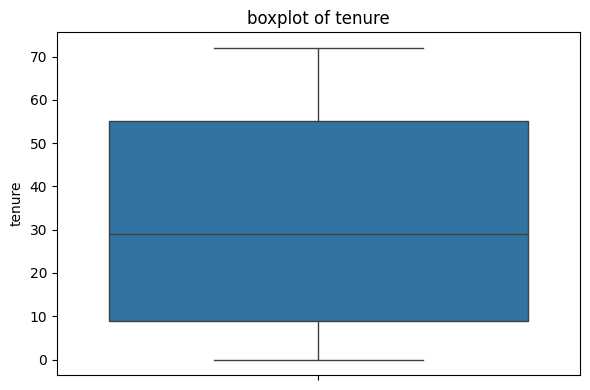

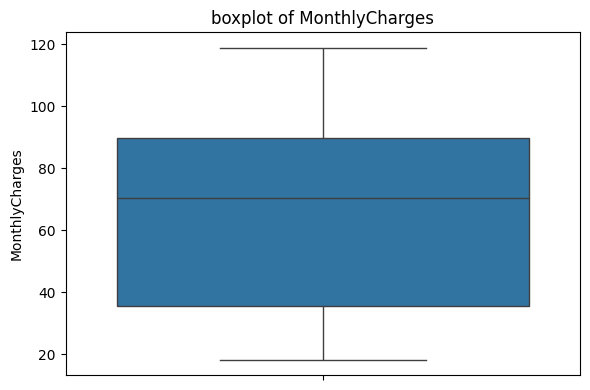

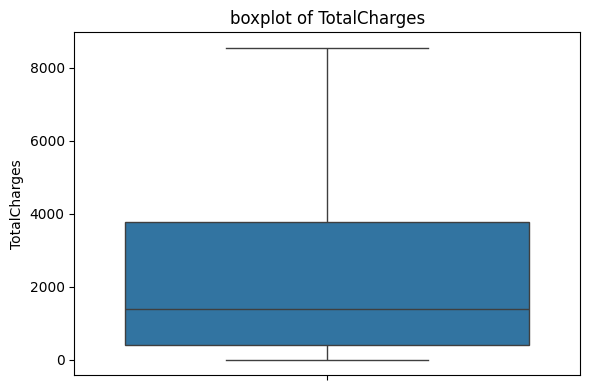

In [ ]:
for col in num_cols:
    plt.figure(figsize=(6, 4))
    sns.boxplot(data=df_copy, y=col)
    plt.title(f"boxplot of {col}")
    plt.tight_layout()
    plt.show()

In [ ]:
categ_cols = df_copy.select_dtypes(include=['object']).columns.tolist()
print(categ_cols)

['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


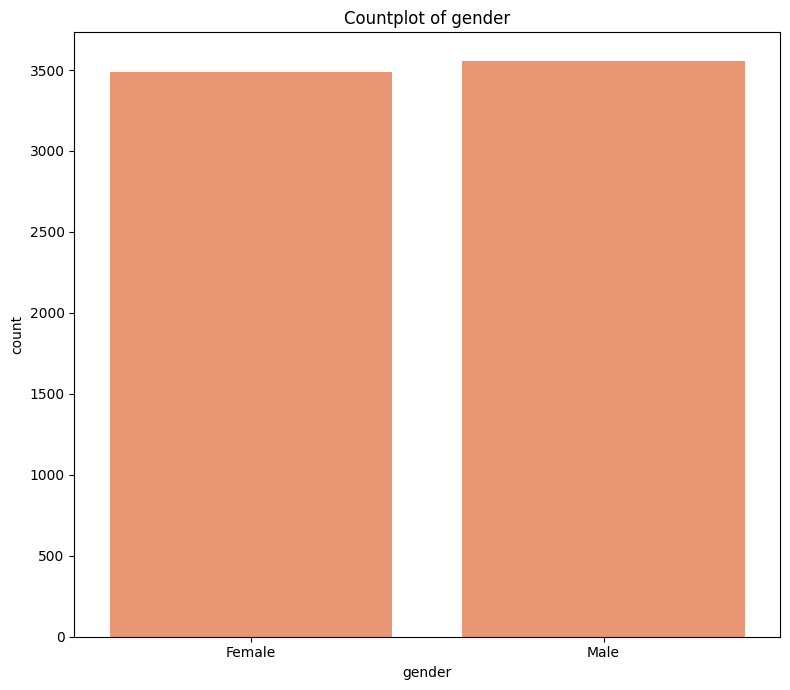

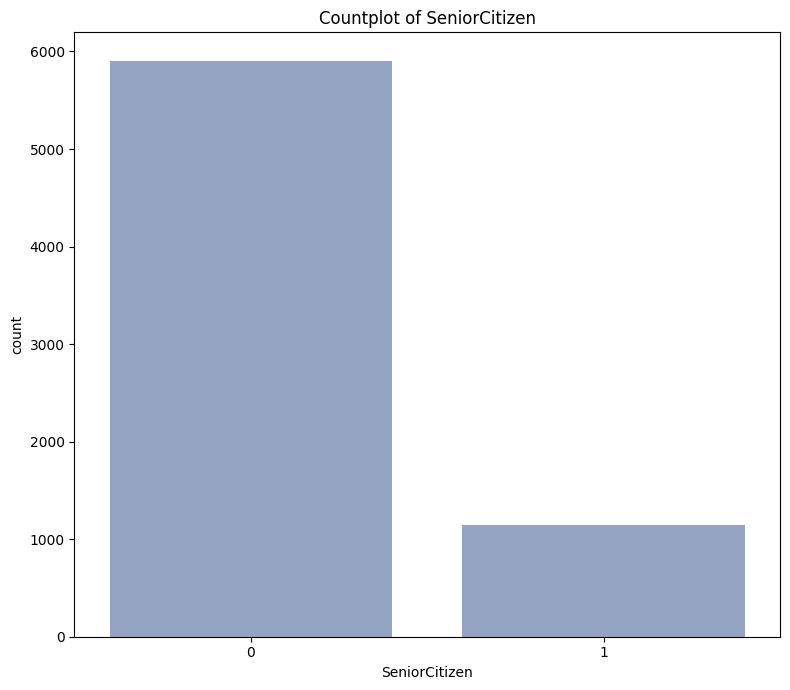

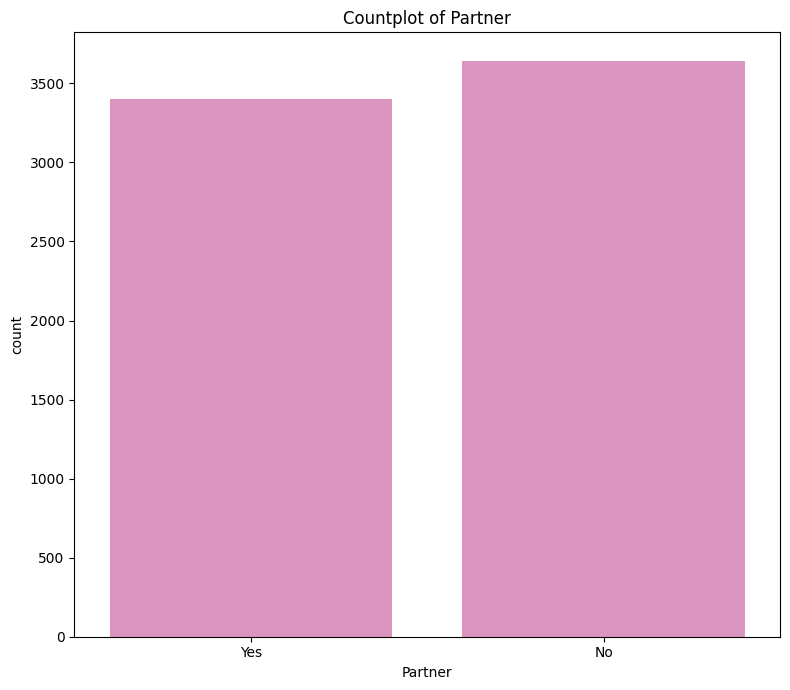

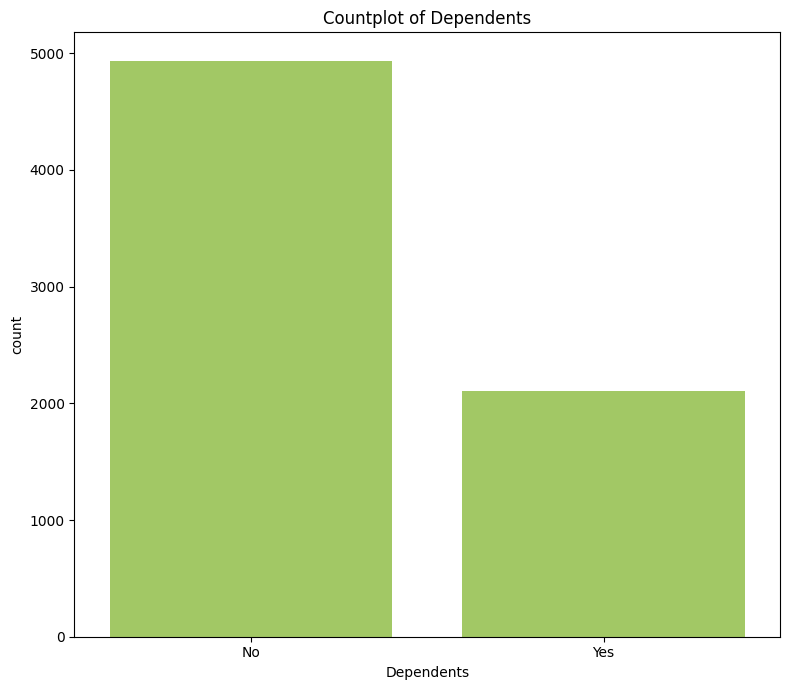

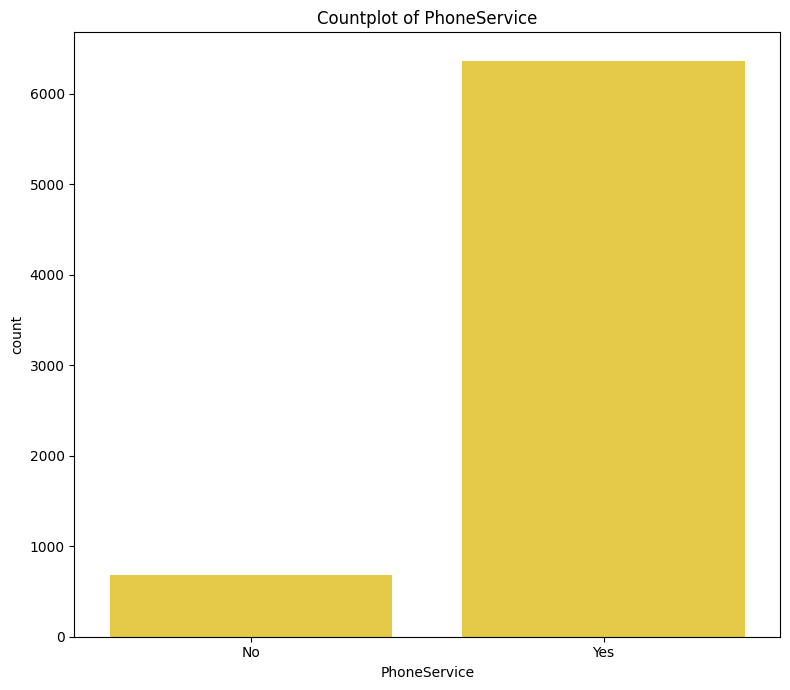

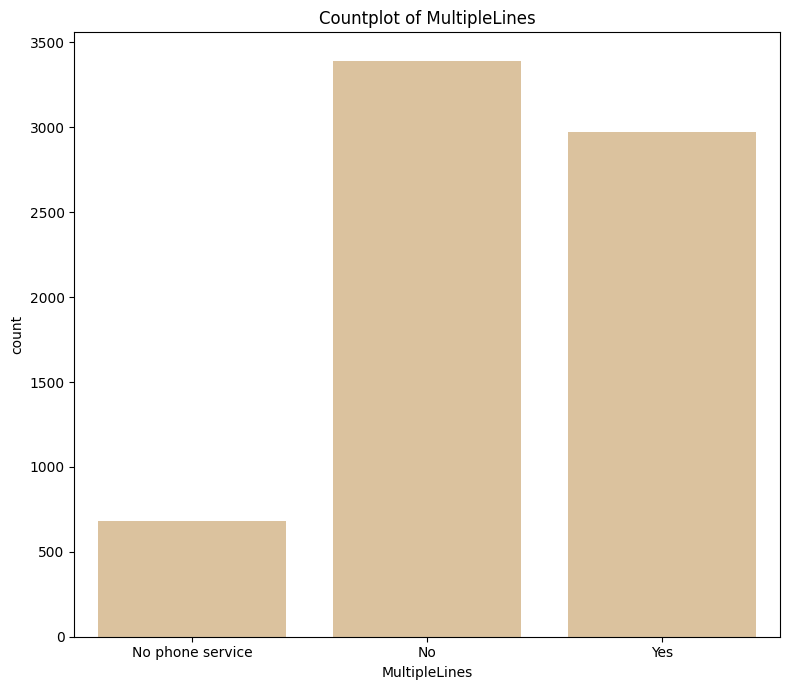

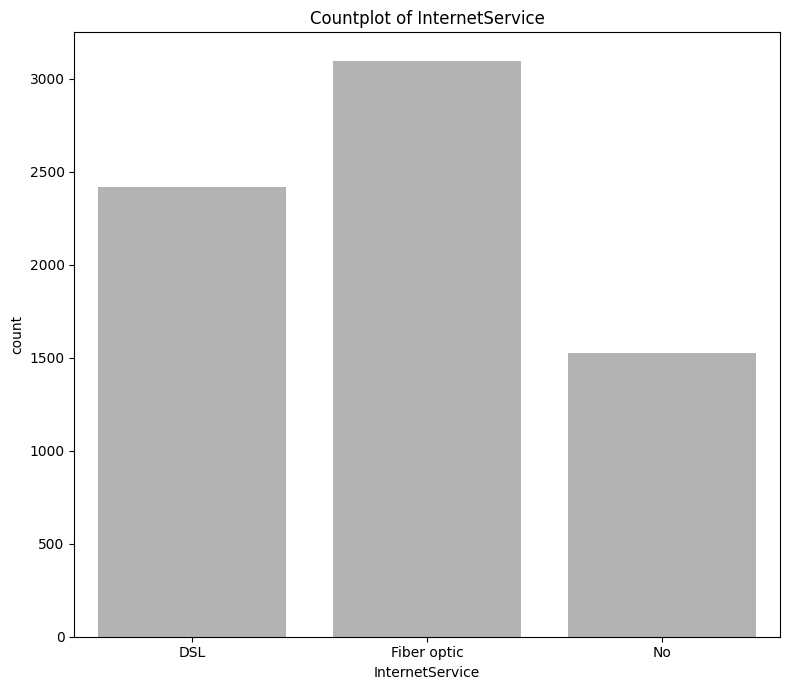

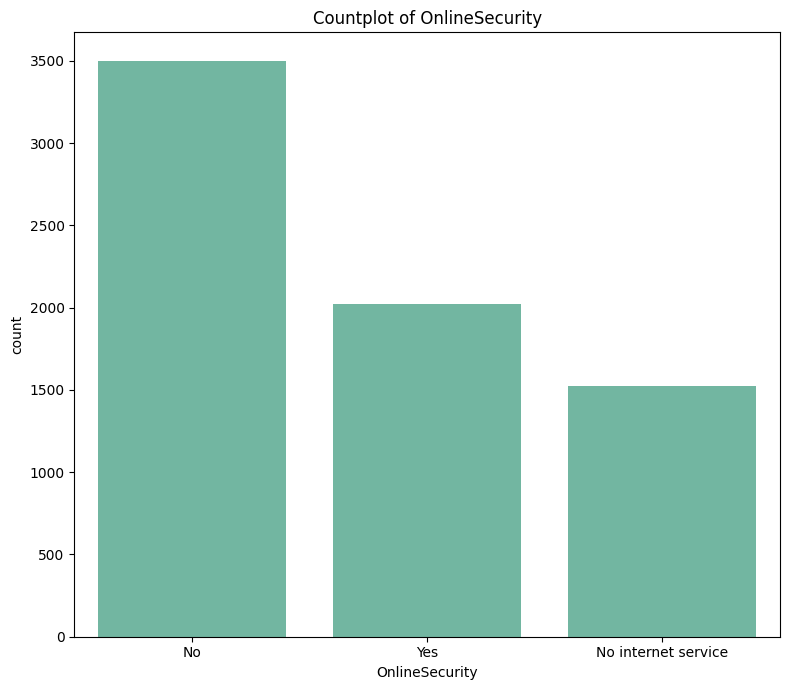

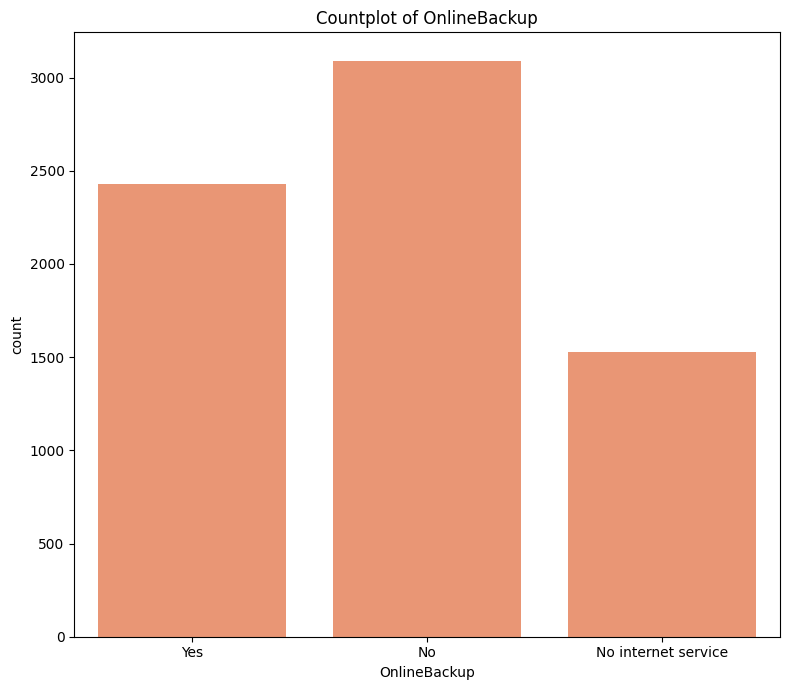

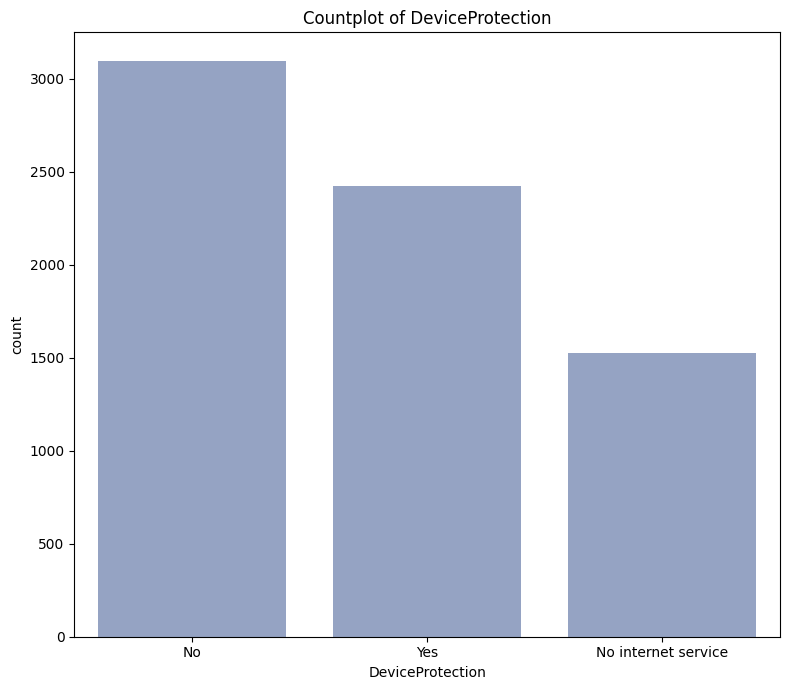

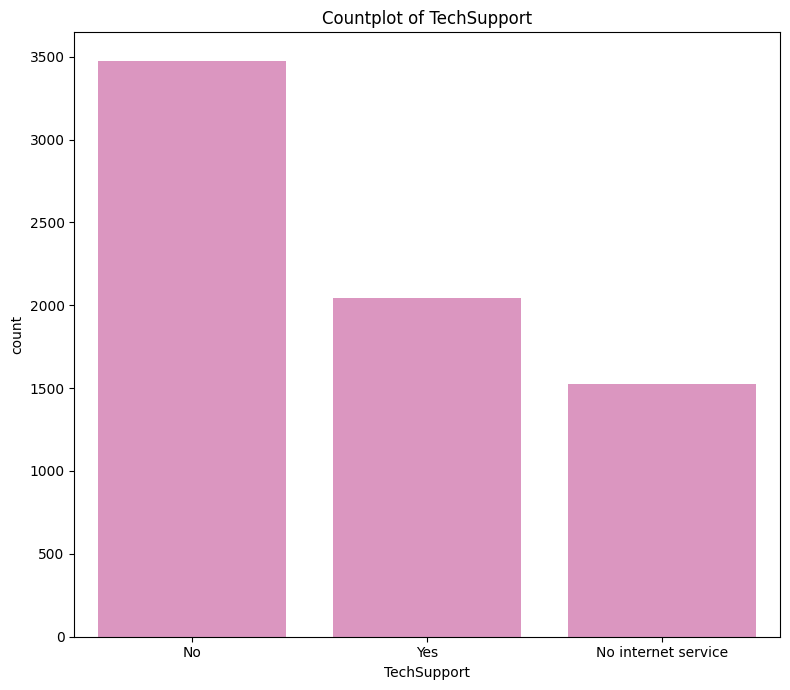

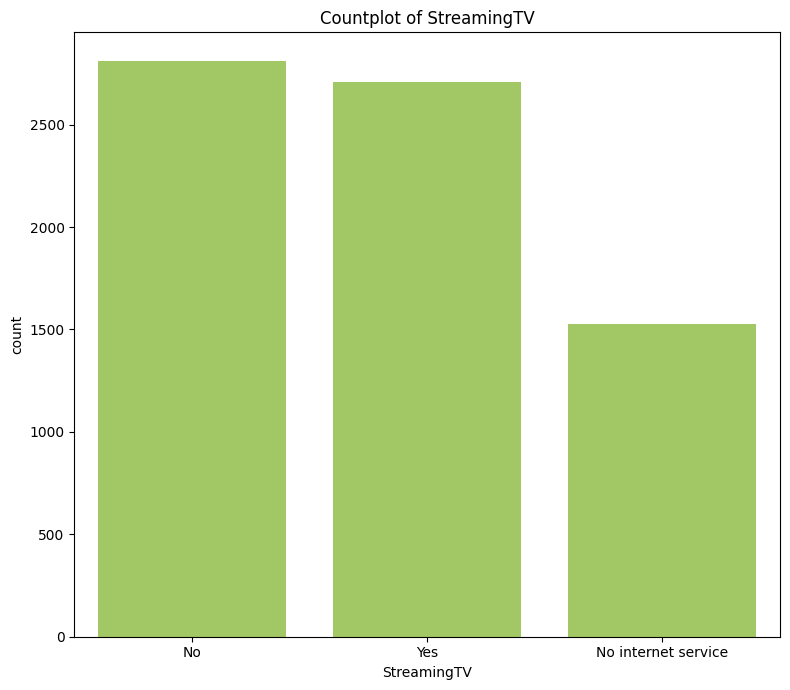

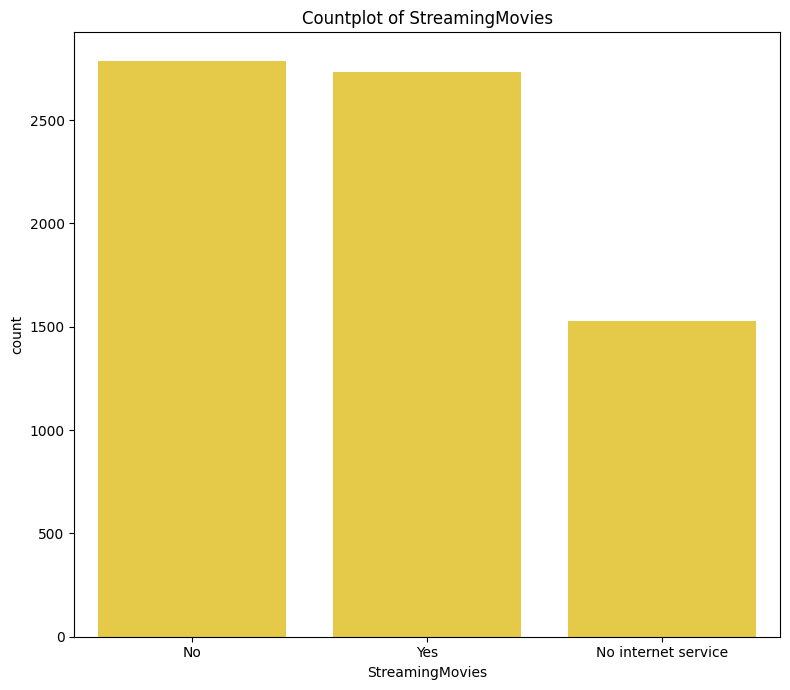

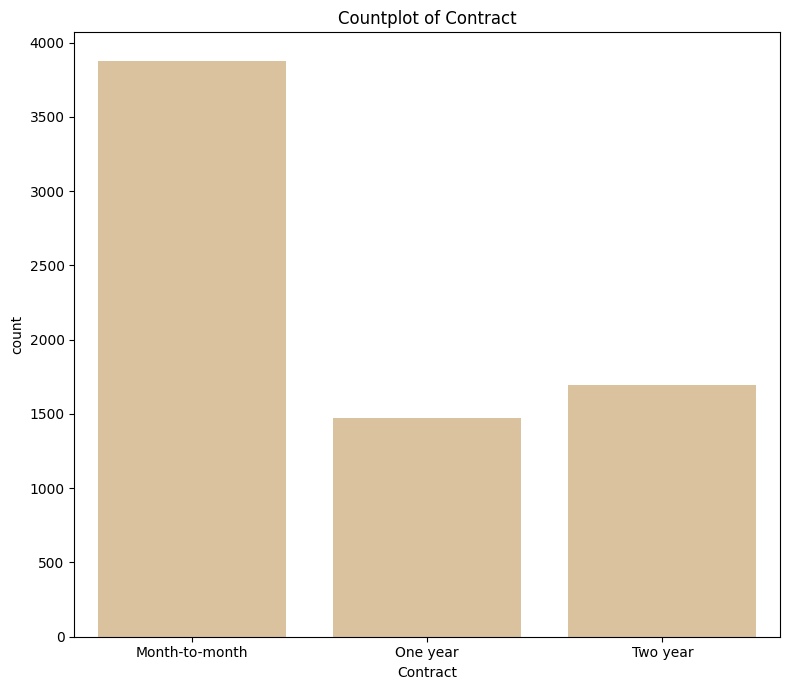

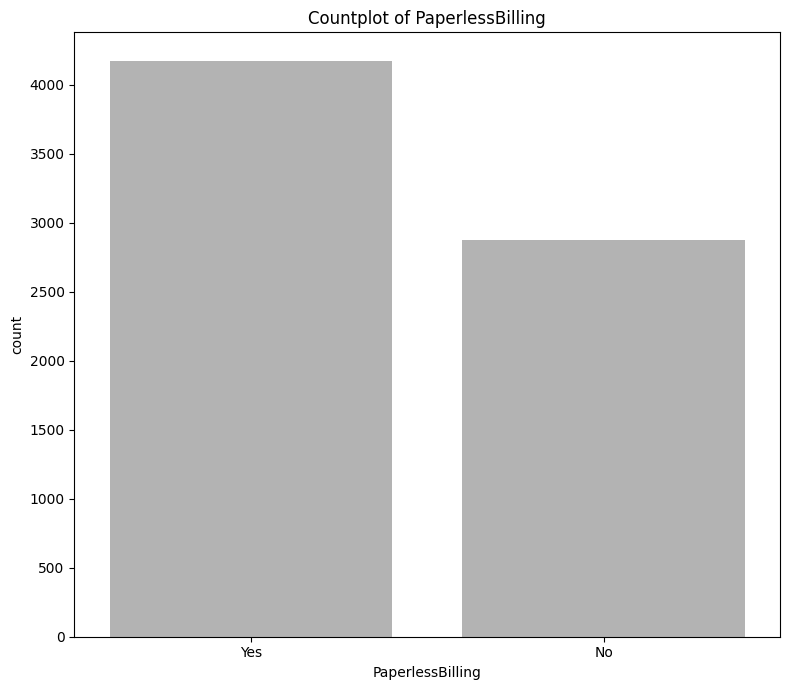

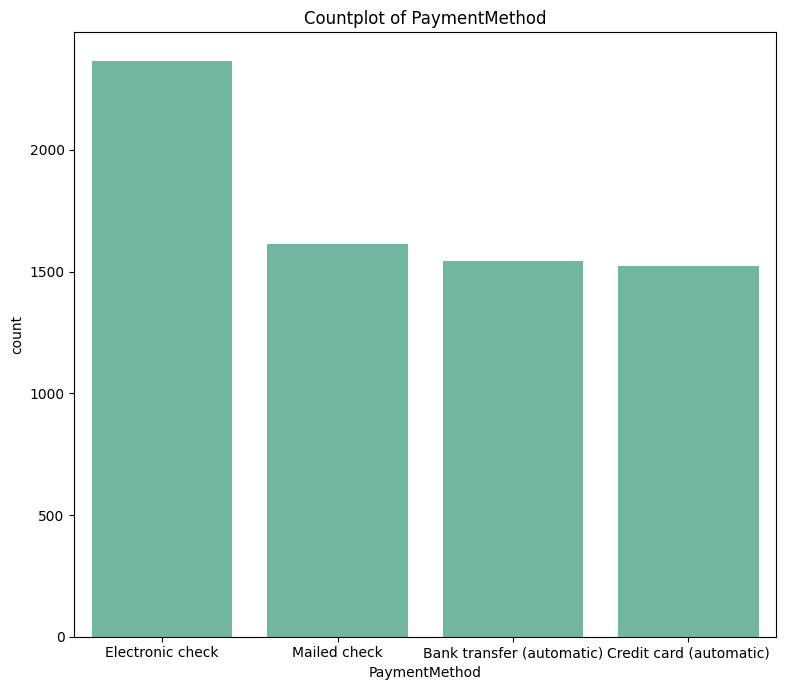

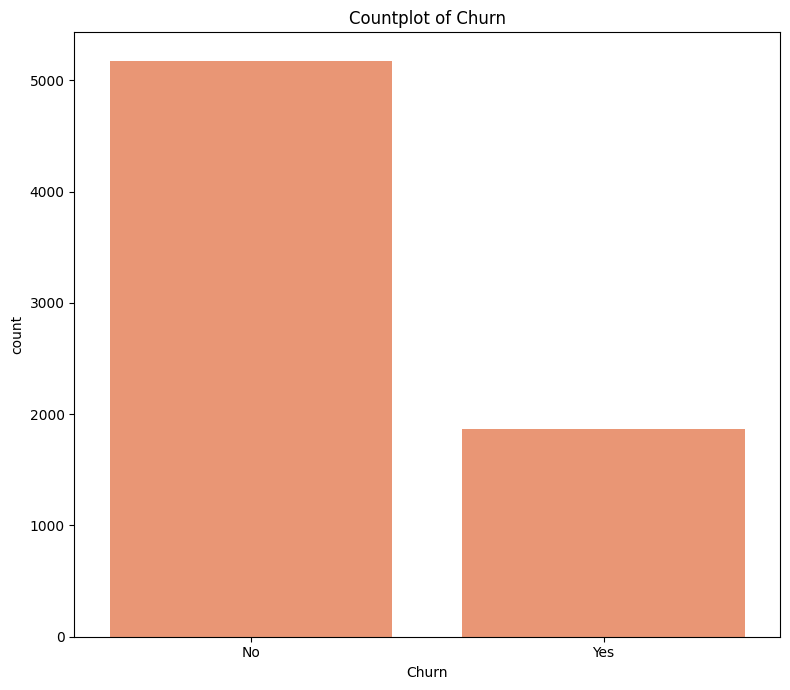

In [ ]:
palette = sns.color_palette("Set2", len(categ_cols))

for i, col in enumerate(categ_cols):
    if col == "customerID":
        continue

    plt.figure(figsize=(8, 7))
    sns.countplot(data=df_copy, x=col, color=palette[i])
    plt.title(f"Countplot of {col}")
    plt.tight_layout()
    plt.show()

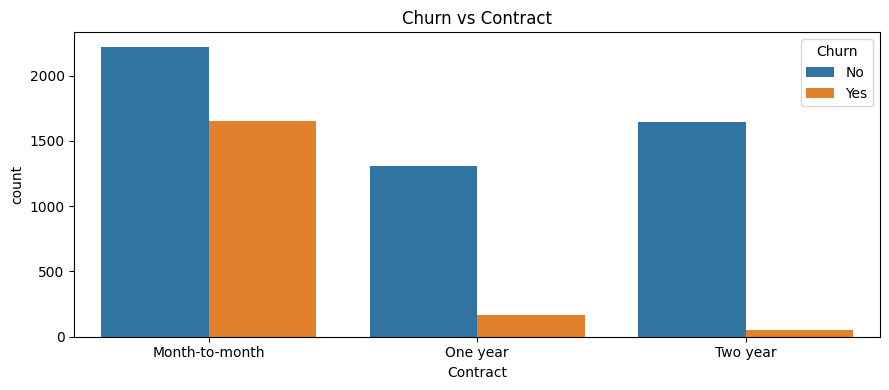

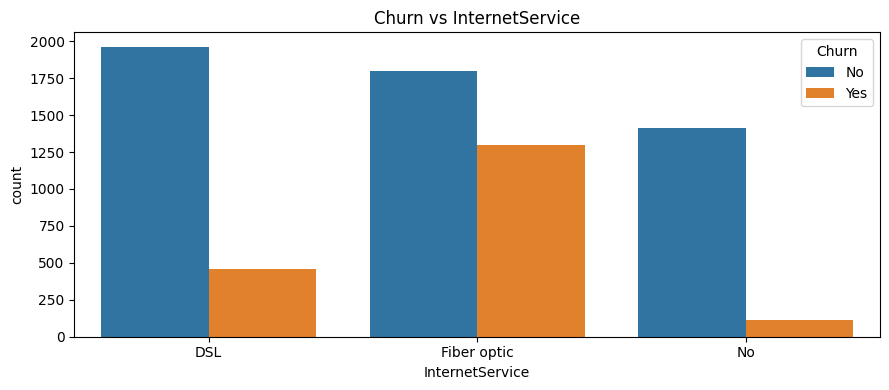

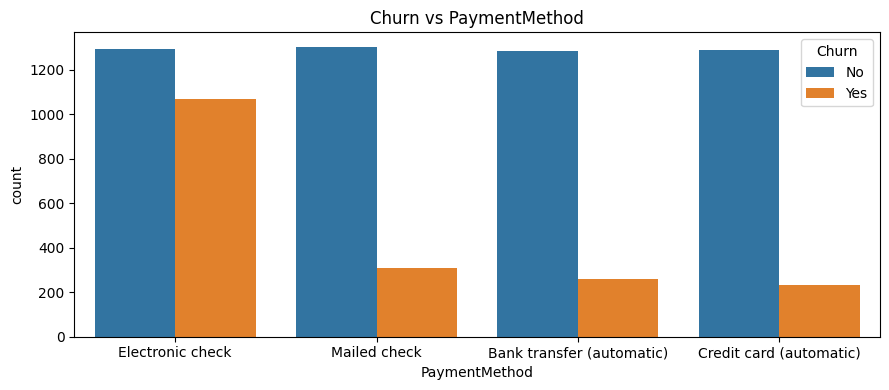

In [ ]:
x = 'Churn'
relations = ['Contract', 'InternetService','PaymentMethod']
for col in relations:
    plt.figure(figsize=(9,4))
    sns.countplot(data=df_copy, x=col, hue ='Churn')
    plt.title(f"Churn vs {col}")
    plt.tight_layout()
    plt.show()

/tmp/ipython-input-464/2736652307.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x="Churn", y = col, palette = "Set2")


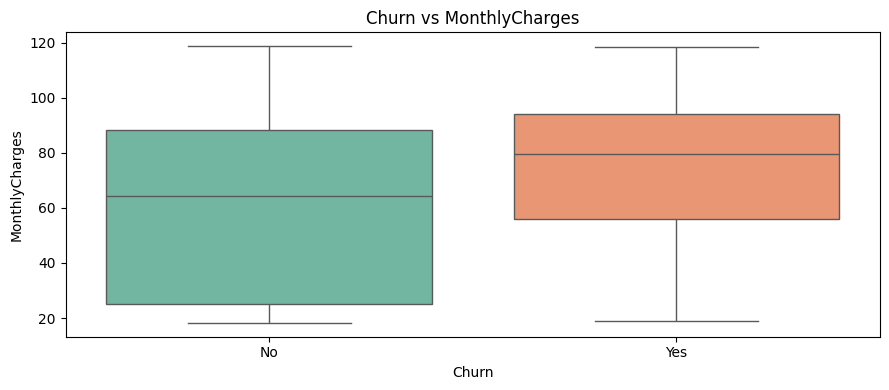

/tmp/ipython-input-464/2736652307.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_copy, x="Churn", y = col, palette = "Set2")


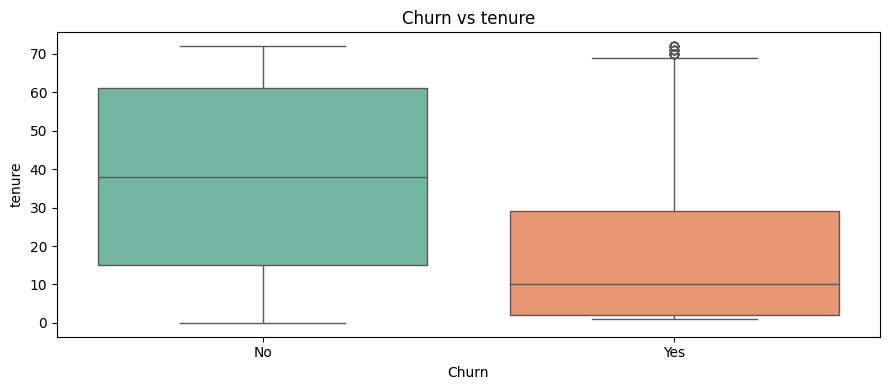

In [ ]:
x = 'Churn'
y = ['MonthlyCharges','tenure']
for col in y:
    plt.figure(figsize=(9,4))
    sns.boxplot(data=df_copy, x="Churn", y = col, palette = "Set2")
    plt.title(f"Churn vs {col}")
    plt.tight_layout()
    plt.show()


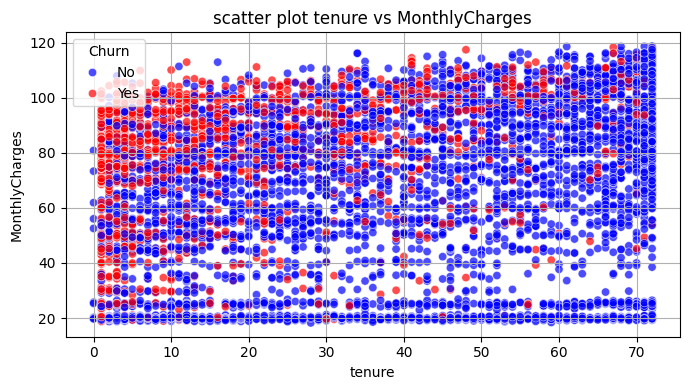

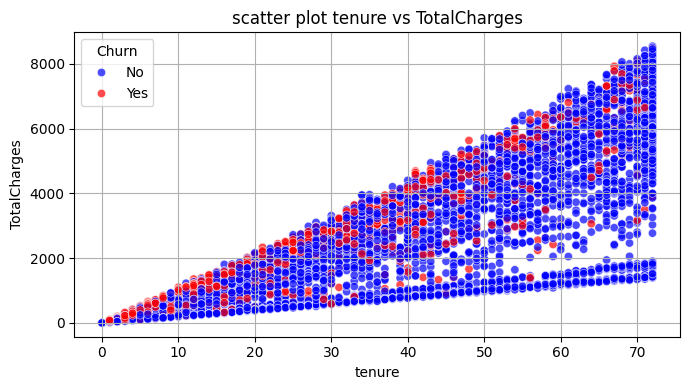

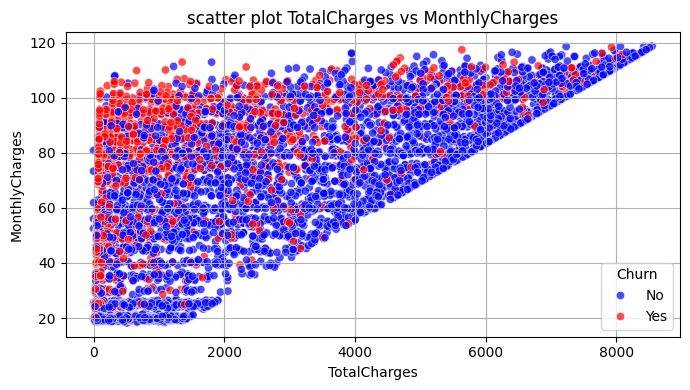

In [ ]:
scatter1 = ['tenure','MonthlyCharges']
scatter2 = ['tenure' , 'TotalCharges']
scatter3 = ['TotalCharges', 'MonthlyCharges']
scatters = [scatter1, scatter2, scatter3]
for col in scatters:
  x_plot, y_plot = col
  plt.figure(figsize=(7,4))
  sns.scatterplot(data=df_copy, x=x_plot, y =y_plot, alpha=0.7, hue='Churn', palette={'Yes': 'red', 'No': 'blue'})
  # plt.xlabel(x_plot)
  # plt.ylabel(y_plot)
  plt.title(f'scatter plot {x_plot} vs {y_plot}')
  plt.tight_layout()
  plt.grid(True)
  plt.show()


In [ ]:
print(df_copy["Churn"].dtype)

float64


In [ ]:
df_copy["Churn"].value_counts(dropna=False)

,count
Churn,
NaN,7043


In [ ]:
df_copy = churn.copy()

In [ ]:
df_copy["Churn"] = df_copy["Churn"].astype(str).str.strip().str.lower()
df_copy["Churn"] = df_copy["Churn"].map({"no":0, "yes":1})

In [ ]:
print(df_copy["Churn"].dtype)

int64


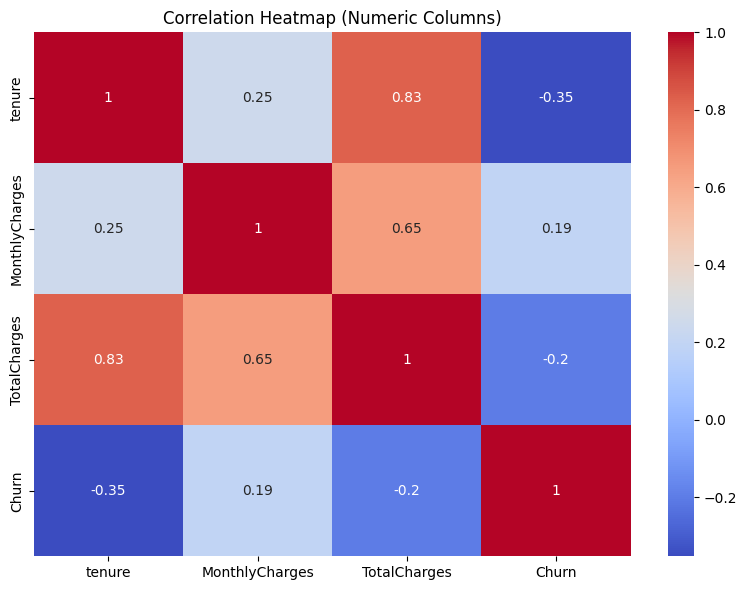

Churn             1.000000
MonthlyCharges    0.193356
TotalCharges     -0.199484
tenure           -0.352229
Name: Churn, dtype: float64


In [ ]:
num_cols = df_copy.select_dtypes(include=[np.number]).columns
corr = df_copy[num_cols].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap (Numeric Columns)")
plt.tight_layout()
plt.show()

print(corr["Churn"].sort_values(ascending=False))